<h1 style="font-size: 35pt; color: #58B2DC; font-family: sans-serif; font-weight: bold;">Introduction</h1>

<div style="font-size: 15pt; font-family: sans-serif;">
    Welcome to my notebook!<br>
    In this notebook, I introduce nueral network model by pytorch. NN models can be as good as GBDT(Gradient Boosted Decision Tree).
</div>

<h1 style="font-size: 35pt; color: #58B2DC; font-family: sans-serif; font-weight: bold;">
    Import Library
</h1>

In [1]:
import warnings
warnings.filterwarnings("ignore") # Ignore all warnings
# import os
# os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
# for automatic EDA
from pandas_profiling import ProfileReport
# preprocess, split data, model, and metrics
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score
# pytorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
# for plot result
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('fivethirtyeight')

# Check the path of data
import os
for dirname, _, filenames in os.walk('/kaggle/input/titanic'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        
SEED = 42 # for Reproducibililty

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


<h1 style="font-size: 35pt; color: #58B2DC; font-family: sans-serif; font-weight: bold;">
    Read Data
</h1>

In [2]:
train_df = pd.read_csv('/kaggle/input/titanic/train.csv')
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


<div style="font-size: 15pt; font-family: sans-serif;">
    There are some null values and categorical columns so we need to define feature engineering.
</div>

<h1 style="font-size: 35pt; color: #58B2DC; font-family: sans-serif; font-weight: bold;">
    Feature Engineering
</h1>

<div style="font-size: 15pt; font-family: sans-serif;">
    Define some process.<br>
    <ol>
        <li>fill null values</li>
        <li>extract title in name</li>
        <li>categorical to label encoding</li>
        <li>standardization</li>
        <li>extract passengers in group</li>
</div>

In [3]:
def titanic_preprocessing(input_df):
    df = input_df.copy()
    # missin values
    # Age is int(or float) so use mean or median
    # Embarked is caterogy(label) so use mode
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    df['Fare'] = df['Fare'].fillna(df['Fare'].median()) # Fare is missing in test data
    # extract title
    df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    df['Title'] = df['Title'].replace('Mlle', 'Miss')
    df['Title'] = df['Title'].replace('Ms', 'Miss')
    df['Title'] = df['Title'].replace('Mme', 'Mrs')
    # Label Encoding
    # let the string category feature to integer
    le = LabelEncoder()
    df['Pclass'] = le.fit_transform(df['Pclass'])
    df['Sex'] = le.fit_transform(df['Sex'])
    df['Embarked'] = le.fit_transform(df['Embarked'])
    df['Title'] = le.fit_transform(df['Title'])
    # Standardize
    # Scaling int or float feature, it improve prediction for especially Neural Network Model.
    sc = StandardScaler()
    df[['Age', 'Fare']] = sc.fit_transform(df[['Age', 'Fare']])
    # Get the number of passenger in each group
    df['PassengersInGroup'] = df['SibSp'] + df['Parch'] + 1 # Siblings/Spouses + Parent/Children + him/herself
    df['IsAlone'] = df['PassengersInGroup'].apply(lambda x: 1 if x == 1 else 0)
    # drop sibsp and parch because these have high correlation for PassengersInGroup
    df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch'])
    return df

In [4]:
train_data = titanic_preprocessing(train_df)
train_data.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,PassengersInGroup,IsAlone
0,0,2,1,-0.565736,-0.502445,2,2,2,0
1,1,0,0,0.663861,0.786845,0,3,2,0
2,1,2,0,-0.258337,-0.488854,2,1,1,1
3,1,0,0,0.433312,0.420730,2,3,2,0
4,0,2,1,0.433312,-0.486337,2,2,1,1


In [5]:
feature_cols = train_data.columns.tolist()
target_col = 'Survived'
feature_cols.remove(target_col)

In [6]:
x_train, y_train = train_data[feature_cols].to_numpy(), train_data[[target_col]].to_numpy()

<h1 style="font-size: 35pt; color: #58B2DC; font-family: sans-serif; font-weight: bold;">
    Build Model
</h1>

<div style="font-size: 15pt; font-family: sans-serif;">
    Build Neural Network Model by PyTorch.
</div>

In [7]:
class NNModel(nn.Module):
    def __init__(self, input_shape):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_shape, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(8, 1),
            nn.Sigmoid(),
        )
    
    def forward(self, x):
        y = self.layers(x)
        return y

In [8]:
# if you use GPU, you should set device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

x_train_tensor = torch.as_tensor(x_train, dtype=torch.float)
y_train_tensor = torch.as_tensor(y_train, dtype=torch.float)
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True,
)

lr = 0.01

torch.manual_seed(42) # for reproducibility

# define model. don't forget to(device) if you use GPU
model = NNModel(x_train_tensor.size()[1]).to(device)
# optimizer
optimizer = optim.Adam(model.parameters(), lr=lr)
# loss function
loss_fn = nn.BCELoss()

In [9]:
n_epochs = 100
for epoch in range(1, n_epochs + 1):
    # set model to train mode
    model.train()
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
    
        # reset gradient calculation
        optimizer.zero_grad()
        # get prediction
        yhat = model(x_batch)
        # calculate loss
        loss = loss_fn(yhat, y_batch)
        # backward propagation to calculate gradient
        loss.backward()
        # update weight parameters
        optimizer.step()

model.eval()
y_proba = model(x_train_tensor.to(device)).detach().cpu().numpy()
nn_acc = accuracy_score(y_train, [1 if proba > 0.5 else 0 for proba in y_proba])
nn_auc = roc_auc_score(y_train, y_proba)
print(f'Accuracy: {nn_acc:.4f}, ROC-AUC: {nn_auc:.4f}')

Accuracy: 0.8474, ROC-AUC: 0.9008


<h2 style="font-size: 25pt; color: #58B2DC; font-family: sans-serif; font-weight: bold;">
    Explore layers
</h2>

<h3 style="font-size: 20pt; font-family: sans-serif; font-weight: bold;">
    Categorical Embeddings
</h3>

<div style="font-size: 15pt; font-family: sans-serif;">
    Simple Neural Network Model is not bad but try some layers to improve scores.<br>
    To treat categorical columns, we introduce <b>Categorical Embedding</b>.<br>
    Model image is below.
</div>

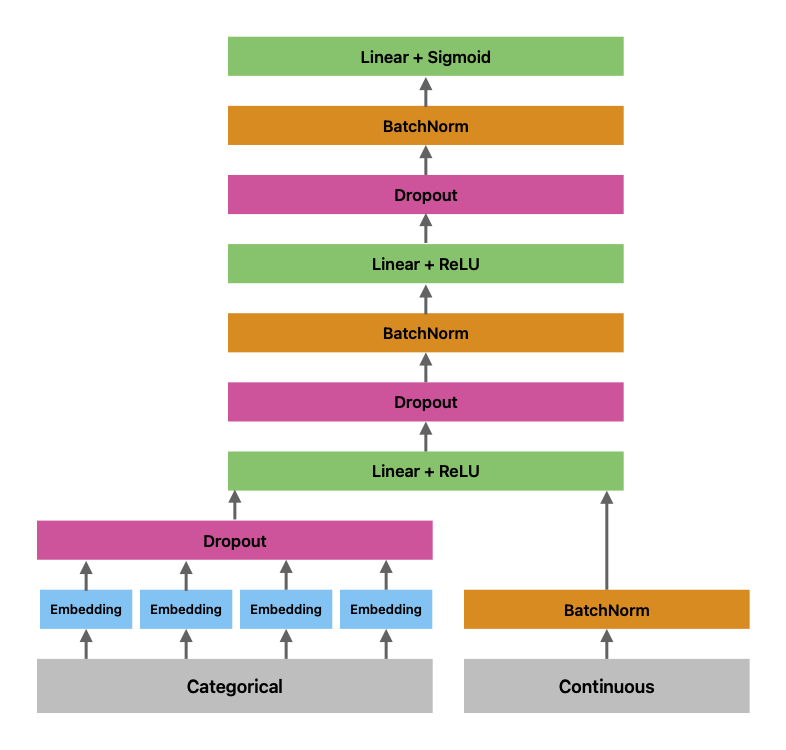

In [10]:
class NNModelWithCategoricalEmbedding(nn.Module):
    def __init__(self, embedding_sizes, n_continuous, layer_sizes, output_size, p=0.5):
        super().__init__()
        
        self.embeddings = nn.ModuleList([nn.Embedding(ni, nf) for ni, nf in embedding_sizes])
        self.embedding_drop = nn.Dropout(p)
        self.batch_norm_con = nn.BatchNorm1d(n_continuous)
        
        layer_sizes = [sum([nf for _,nf in embedding_sizes]) + n_continuous] + layer_sizes
        self.layers = nn.ModuleList([
            nn.Linear(layer_sizes[i], layer_sizes[i+1]) 
            for i in range(len(layer_sizes)-1)
        ])
        self.batch_norms = nn.ModuleList([
            nn.BatchNorm1d(layer_sizes[i+1]) 
            for i in range(len(layer_sizes)-1)
        ])
        
        for layer in self.layers:
            nn.init.kaiming_uniform_(layer.weight.data)
        
        self.output = nn.Linear(layer_sizes[-1], output_size)
        nn.init.kaiming_uniform_(self.output.weight.data)
        
        self.dropout = nn.Dropout(p)
        
    def forward(self, x_categorical, x_continuous):
        embeddings = []
        for i,e in enumerate(self.embeddings):
            embeddings.append(e(x_categorical[:, i]))
        x = torch.cat(embeddings, 1)
        x = self.embedding_drop(x)
        
        x_cont = self.batch_norm_con(x_continuous)
        x = torch.cat([x, x_cont], 1)
        
        for batch_norm, layer in zip(self.batch_norms, self.layers):
            x = nn.ReLU()(layer(x))
            x = self.dropout(x)
            x = batch_norm(x)
        
        x = self.output(x)
        x = nn.Sigmoid()(x)
        return x

In [11]:
# ni is label size, nf is output size(to 5)
embedding_sizes = [
    (3, 5), # Pclass
    (2, 5), # Sex
    (3, 5), # Embarked
    (5, 5), # Title
    (2, 5), # IsAlone
]
n_continuous = 3 # Age Fare PassengersInGroup
layer_sizes = [16, 8]
output_size = 1

In [12]:
cat_cols = ['Pclass', 'Sex', 'Embarked', 'Title', 'IsAlone']
con_cols = ['Age', 'Fare', 'PassengersInGroup']
x_cat, x_con, y = train_data[cat_cols].to_numpy(), train_data[con_cols].to_numpy(), train_data[[target_col]].to_numpy()
x_cat_tensor, x_con_tensor, y_tensor = torch.as_tensor(x_cat, dtype=torch.int), torch.as_tensor(x_con, dtype=torch.float), torch.as_tensor(y, dtype=torch.float)
train_dataset = TensorDataset(x_cat_tensor, x_con_tensor, y_train_tensor)
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True,
)

In [13]:
lr = 0.01

torch.manual_seed(42) # for reproducibility

# define model. don't forget to(device) if you use GPU
model_cat = NNModelWithCategoricalEmbedding(embedding_sizes, n_continuous, layer_sizes, output_size).to(device)
# optimizer
optimizer = optim.Adam(model_cat.parameters(), lr=lr)
# loss function
loss_fn = nn.BCELoss()

In [14]:
n_epochs = 1000
for epoch in range(1, n_epochs + 1):
    # set model to train mode
    model_cat.train()
    
    for x_cat_batch, x_con_batch, y_batch in train_loader:
        x_cat_batch, x_con_batch, y_batch = x_cat_batch.to(device), x_con_batch.to(device), y_batch.to(device)
        # reset gradient calculation
        optimizer.zero_grad()
        # get prediction
        yhat = model_cat(x_cat_batch, x_con_batch)
        # calculate loss
        loss = loss_fn(yhat, y_batch)
        # backward propagation to calculate gradient
        loss.backward()
        # update weight parameters
        optimizer.step()

model_cat.eval()
y_proba = model_cat(x_cat_tensor.to(device), x_con_tensor.to(device)).detach().cpu().numpy()
nn_acc = accuracy_score(y_train, [1 if proba > 0.5 else 0 for proba in y_proba])
nn_auc = roc_auc_score(y_train, y_proba)
print(f'Accuracy: {nn_acc:.4f}, ROC-AUC: {nn_auc:.4f}')

Accuracy: 0.8350, ROC-AUC: 0.8791


<h3 style="font-size: 20pt; font-family: sans-serif; font-weight: bold;">
    Numerical Embeddings(Linear)
</h3>

<div style="font-size: 15pt; font-family: sans-serif;">
    Can I apply "Embedding for Numerical Features"? In this section, I will introduce <b>Linear</b> Embedding.<br>
    Model image is below.
</div>

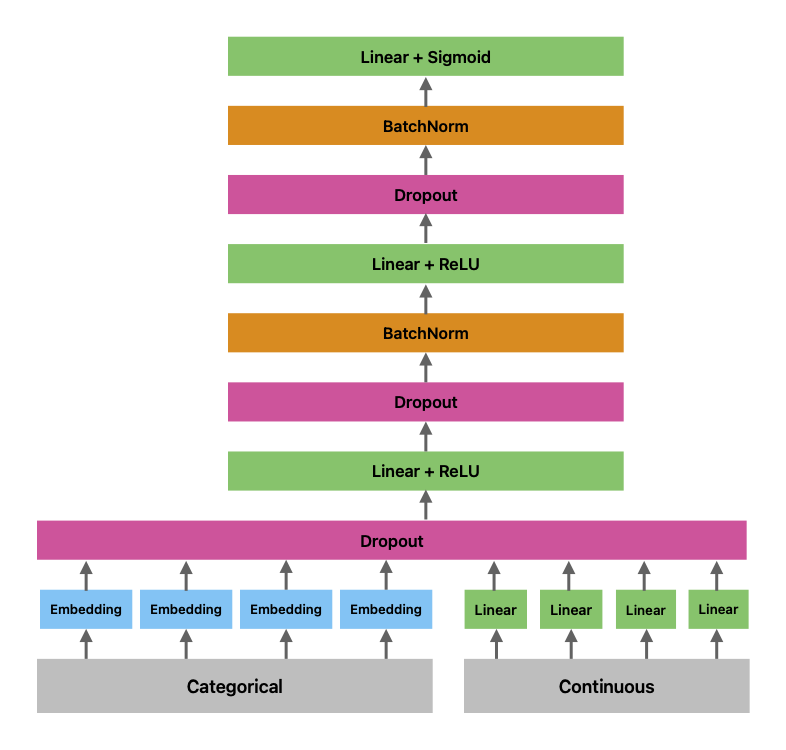

In [15]:
class NNModelWithLE(nn.Module):
    def __init__(self, cat_embedding_sizes, con_embedding_sizes, layer_sizes, output_size, p=0.5):
        super().__init__()
        
        self.cat_embeddings = nn.ModuleList([nn.Embedding(ni, nf) for ni, nf in cat_embedding_sizes])
        self.con_embeddings = nn.ModuleList([nn.Linear(1, nf) for nf in con_embedding_sizes])
        
        self.embedding_drop = nn.Dropout(p)
        
        layer_sizes = [sum([nf for _,nf in cat_embedding_sizes]) + sum(con_embedding_sizes)] + layer_sizes
        self.layers = nn.ModuleList([
            nn.Linear(layer_sizes[i], layer_sizes[i+1]) 
            for i in range(len(layer_sizes)-1)
        ])
        self.batch_norms = nn.ModuleList([
            nn.BatchNorm1d(layer_sizes[i+1]) 
            for i in range(len(layer_sizes)-1)
        ])
        
        for layer in self.layers:
            nn.init.kaiming_uniform_(layer.weight.data)
        
        self.output = nn.Linear(layer_sizes[-1], output_size)
        nn.init.kaiming_uniform_(self.output.weight.data)
        
        self.dropout = nn.Dropout(p)
        
    def forward(self, x_categorical, x_continuous):
        embeddings = []
        for i,e in enumerate(self.cat_embeddings):
            embeddings.append(e(x_categorical[:, i]))
        for i,e in enumerate(self.con_embeddings):
            embeddings.append(e(x_continuous[:, [i]]))
        x = torch.cat(embeddings, 1)
        x = self.embedding_drop(x)
        
        for batch_norm, layer in zip(self.batch_norms, self.layers):
            x = nn.ReLU()(layer(x))
            x = self.dropout(x)
            x = batch_norm(x)
        
        x = self.output(x)
        x = nn.Sigmoid()(x)
        return x

In [16]:
# ni is label size, nf is output size(to 5)
cat_embedding_sizes = [
    (3, 5), # Pclass
    (2, 5), # Sex
    (3, 5), # Embarked
    (5, 5), # Title
    (2, 5), # IsAlone
]
con_embedding_sizes = [5, 5, 5] # Age Fare PassengersInGroup
layer_sizes = [16, 8]
output_size = 1

In [17]:
cat_cols = ['Pclass', 'Sex', 'Embarked', 'Title', 'IsAlone']
con_cols = ['Age', 'Fare', 'PassengersInGroup']
x_cat, x_con, y = train_data[cat_cols].to_numpy(), train_data[con_cols].to_numpy(), train_data[[target_col]].to_numpy()
x_cat_tensor, x_con_tensor, y_tensor = torch.as_tensor(x_cat, dtype=torch.int), torch.as_tensor(x_con, dtype=torch.float), torch.as_tensor(y, dtype=torch.float)
train_dataset = TensorDataset(x_cat_tensor, x_con_tensor, y_train_tensor)
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True,
)

In [18]:
lr = 0.01

torch.manual_seed(42) # for reproducibility

# define model. don't forget to(device) if you use GPU
model_le = NNModelWithLE(cat_embedding_sizes, con_embedding_sizes, layer_sizes, output_size).to(device)
# optimizer
optimizer = optim.Adam(model_le.parameters(), lr=lr)
# loss function
loss_fn = nn.BCELoss()

In [19]:
n_epochs = 1000
for epoch in range(1, n_epochs + 1):
    # set model to train mode
    model_le.train()
    
    for x_cat_batch, x_con_batch, y_batch in train_loader:
        x_cat_batch, x_con_batch, y_batch = x_cat_batch.to(device), x_con_batch.to(device), y_batch.to(device)
        # reset gradient calculation
        optimizer.zero_grad()
        # get prediction
        yhat = model_le(x_cat_batch, x_con_batch)
        # calculate loss
        loss = loss_fn(yhat, y_batch)
        # backward propagation to calculate gradient
        loss.backward()
        # update weight parameters
        optimizer.step()

model_le.eval()
y_proba = model_le(x_cat_tensor.to(device), x_con_tensor.to(device)).detach().cpu().numpy()
nn_acc = accuracy_score(y_train, [1 if proba > 0.5 else 0 for proba in y_proba])
nn_auc = roc_auc_score(y_train, y_proba)
print(f'Accuracy: {nn_acc:.4f}, ROC-AUC: {nn_auc:.4f}')

Accuracy: 0.8406, ROC-AUC: 0.8802


<h3 style="font-size: 20pt; font-family: sans-serif; font-weight: bold;">
    Numerical Embeddings(Piecewise Linear Encoding)
</h3>

<div style="font-size: 15pt; font-family: sans-serif;">
    In this section, I will introduce <b>Piecewise Linear Encoding(PLE) Embedding</b>.<br>
    Model image is below.
</div>

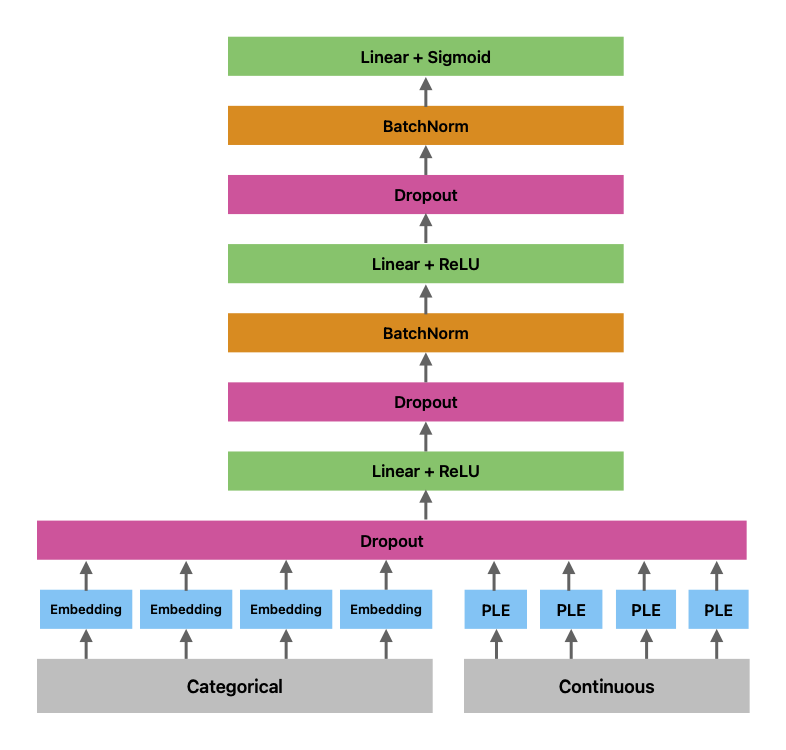

In [20]:
class PiecewiseLinear(nn.Module):
    def __init__(self, quantile_list):
        super().__init__()
        self.quantiles = [[b_tm1, b_t] for b_tm1, b_t in zip(quantile_list[:-1], quantile_list[1:])]
        
    def forward(self, x):
        x_enc = [self.encoding(x, b_tm1, b_t) for b_tm1, b_t in self.quantiles]
        y = torch.cat(x_enc, 1)
        return y
    
    def encoding(self, x, b_tm1, b_t):
        y = (torch.clamp(x, min=b_tm1, max=b_t) - b_tm1) / (b_t - b_tm1)
        return y

In [21]:
class NNModelWithPLE(nn.Module):
    def __init__(self, cat_embedding_sizes, con_embedding_sizes, con_quantile_list, layer_sizes, output_size, p=0.5):
        super().__init__()
        
        self.cat_embeddings = nn.ModuleList([nn.Embedding(ni, nf) for ni, nf in cat_embedding_sizes])
        self.con_ple = nn.ModuleList([PiecewiseLinear(quantiles) for quantiles in con_quantile_list])
        self.con_linear = nn.ModuleList([nn.Linear(ni, nf) for ni, nf in con_embedding_sizes])
        
        self.embedding_drop = nn.Dropout(p)
        
        layer_sizes = [sum([nf for _,nf in cat_embedding_sizes]) + sum([nf for _,nf in con_embedding_sizes])] + layer_sizes
        self.layers = nn.ModuleList([
            nn.Linear(layer_sizes[i], layer_sizes[i+1]) 
            for i in range(len(layer_sizes)-1)
        ])
        self.batch_norms = nn.ModuleList([
            nn.BatchNorm1d(layer_sizes[i+1]) 
            for i in range(len(layer_sizes)-1)
        ])
        
        for layer in self.layers:
            nn.init.kaiming_uniform_(layer.weight.data)
        
        self.output = nn.Linear(layer_sizes[-1], output_size)
        nn.init.kaiming_uniform_(self.output.weight.data)
        
        self.dropout = nn.Dropout(p)
        
    def forward(self, x_categorical, x_continuous):
        embeddings = []
        for i,e in enumerate(self.cat_embeddings):
            embeddings.append(e(x_categorical[:, i]))
        for i, (e_ple, e_l) in enumerate(zip(self.con_ple, self.con_linear)):
            embeddings.append(e_l(e_ple(x_continuous[:, [i]])))
        x = torch.cat(embeddings, 1)
        x = self.embedding_drop(x)
        
        for batch_norm, layer in zip(self.batch_norms, self.layers):
            x = nn.ReLU()(layer(x))
            x = self.dropout(x)
            x = batch_norm(x)
        
        x = self.output(x)
        x = nn.Sigmoid()(x)
        return x

In [22]:
cat_cols = ['Pclass', 'Sex', 'Embarked', 'Title', 'IsAlone']
# con_cols = ['Age', 'Fare', 'PassengersInGroup']
con_cols = ['Age', 'Fare']
x_cat, x_con, y = train_data[cat_cols].to_numpy(), train_data[con_cols].to_numpy(), train_data[[target_col]].to_numpy()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
x_cat_tensor, x_con_tensor, y_tensor = torch.as_tensor(x_cat, dtype=torch.int), torch.as_tensor(x_con, dtype=torch.float), torch.as_tensor(y, dtype=torch.float)
train_dataset = TensorDataset(x_cat_tensor, x_con_tensor, y_tensor)
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True,
)

In [23]:
# ni is label size, nf is output size(to 5)
cat_embedding_sizes = [
    (3, 5), # Pclass
    (2, 5), # Sex
    (3, 5), # Embarked
    (5, 5), # Title
    (2, 5), # IsAlone
]
con_embedding_sizes = [
    (4, 5), # Age
    (4, 5), # Fare
#     (3, 5), # PassengersInGroup
]
con_quantile_list = [
    np.quantile(x_con[:, j], [i / segment_n for i in range(0, segment_n+1)]) 
    for j, (segment_n, _) in enumerate(con_embedding_sizes)
]
layer_sizes = [16, 8]
output_size = 1

In [24]:
lr = 0.01

torch.manual_seed(42) # for reproducibility

# define model. don't forget to(device) if you use GPU
model_ple = NNModelWithPLE(cat_embedding_sizes, con_embedding_sizes, con_quantile_list, layer_sizes, output_size).to(device)
# optimizer
optimizer = optim.Adam(model_ple.parameters(), lr=lr)
# loss function
loss_fn = nn.BCELoss()

In [25]:
n_epochs = 1000
for epoch in range(1, n_epochs + 1):
    # set model to train mode
    model_ple.train()
    
    for x_cat_batch, x_con_batch, y_batch in train_loader:
        x_cat_batch, x_con_batch, y_batch = x_cat_batch.to(device), x_con_batch.to(device), y_batch.to(device)
        # reset gradient calculation
        optimizer.zero_grad()
        # get prediction
        yhat = model_ple(x_cat_batch, x_con_batch)
        # calculate loss
        loss = loss_fn(yhat, y_batch)
        # backward propagation to calculate gradient
        loss.backward()
        # update weight parameters
        optimizer.step()

model_ple.eval()
y_proba = model_ple(x_cat_tensor.to(device), x_con_tensor.to(device)).detach().cpu().numpy()
nn_acc = accuracy_score(y_train, [1 if proba > 0.5 else 0 for proba in y_proba])
nn_auc = roc_auc_score(y_train, y_proba)
print(f'Accuracy: {nn_acc:.4f}, ROC-AUC: {nn_auc:.4f}')

Accuracy: 0.8361, ROC-AUC: 0.8852


<h3 style="font-size: 20pt; font-family: sans-serif; font-weight: bold;">
    Numerical Embeddings(Periodic Embeddings)
</h3>

<div style="font-size: 15pt; font-family: sans-serif;">
    In this section, I will introduce <b>Periodic Embedding</b>.<br>
    Model image is below.
</div>

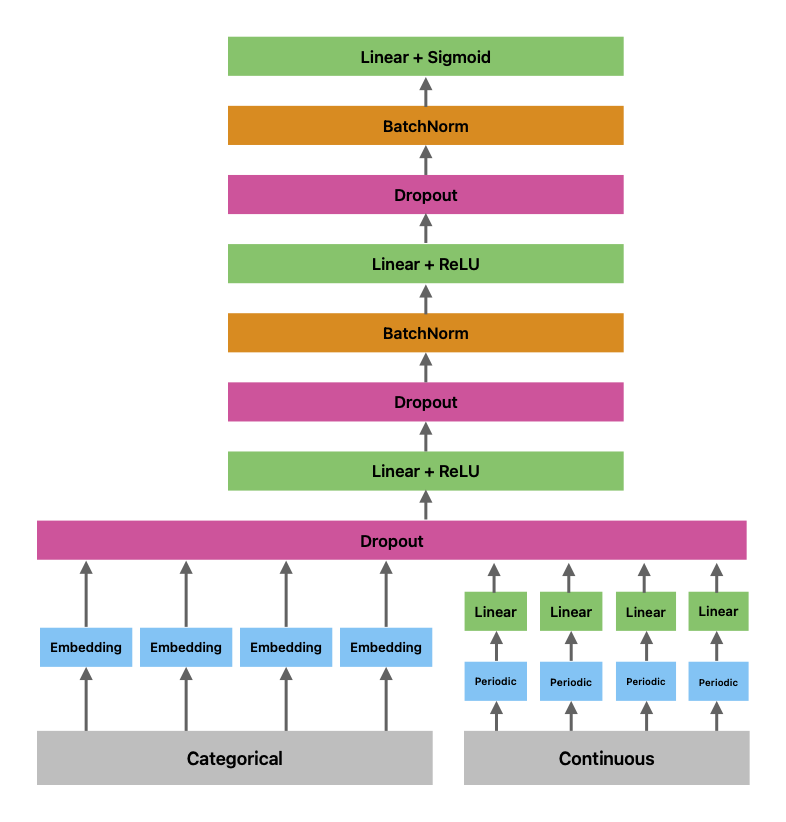

In [26]:
class PeriodicEmbedding(nn.Module):
    def __init__(self, v_size):
        super().__init__()
        self.linear_layer = nn.Linear(1, v_size)
        nn.init.kaiming_normal_(self.linear_layer.weight.data)
        
    def forward(self, x):
        v = 2. * np.pi * self.linear_layer(x)
        sin_v = torch.sin(v)
        cos_v = torch.cos(v)
        y = torch.cat([sin_v, cos_v], 1)
        return y

In [27]:
class NNModelWithPE(nn.Module):
    def __init__(self, cat_embedding_sizes, con_embedding_sizes, layer_sizes, output_size, p=0.5):
        super().__init__()
        
        self.cat_embeddings = nn.ModuleList([nn.Embedding(ni, nf) for ni, nf in cat_embedding_sizes])
        self.con_pe = nn.ModuleList([PeriodicEmbedding(ni) for ni, _ in con_embedding_sizes])
        self.con_linear = nn.ModuleList([nn.Linear(2 * ni, nf) for ni, nf in con_embedding_sizes])
        for layer in self.con_linear:
            nn.init.kaiming_uniform_(layer.weight.data)
        
        self.embedding_drop = nn.Dropout(p)
        
        layer_sizes = [sum([nf for _,nf in cat_embedding_sizes]) + sum([nf for _,nf in con_embedding_sizes])] + layer_sizes
        self.layers = nn.ModuleList([
            nn.Linear(layer_sizes[i], layer_sizes[i+1]) 
            for i in range(len(layer_sizes)-1)
        ])
        for layer in self.layers:
            nn.init.kaiming_uniform_(layer.weight.data)
            
        self.batch_norms = nn.ModuleList([
            nn.BatchNorm1d(layer_sizes[i+1]) 
            for i in range(len(layer_sizes)-1)
        ])
        
        self.output = nn.Linear(layer_sizes[-1], output_size)
        nn.init.kaiming_uniform_(self.output.weight.data)
        
        self.dropout = nn.Dropout(p)
        
    def forward(self, x_categorical, x_continuous):
        embeddings = []
        for i,e in enumerate(self.cat_embeddings):
            embeddings.append(e(x_categorical[:, i]))
        for i, (e_pe, e_l) in enumerate(zip(self.con_pe, self.con_linear)):
            embeddings.append(e_l(e_pe(x_continuous[:, [i]])))
        x = torch.cat(embeddings, 1)
        x = self.embedding_drop(x)
        
        for batch_norm, layer in zip(self.batch_norms, self.layers):
            x = nn.ReLU()(layer(x))
            x = self.dropout(x)
            x = batch_norm(x)
        
        x = self.output(x)
        x = nn.Sigmoid()(x)
        return x

In [28]:
cat_cols = ['Pclass', 'Sex', 'Embarked', 'Title', 'IsAlone']
con_cols = ['Age', 'Fare', 'PassengersInGroup']
x_cat, x_con, y = train_data[cat_cols].to_numpy(), train_data[con_cols].to_numpy(), train_data[[target_col]].to_numpy()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
x_cat_tensor, x_con_tensor, y_tensor = torch.as_tensor(x_cat, dtype=torch.int), torch.as_tensor(x_con, dtype=torch.float), torch.as_tensor(y, dtype=torch.float)
train_dataset = TensorDataset(x_cat_tensor, x_con_tensor, y_tensor)
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True,
)

In [29]:
# ni is label size, nf is output size(to 5)
cat_embedding_sizes = [
    (3, 5), # Pclass
    (2, 5), # Sex
    (3, 5), # Embarked
    (5, 5), # Title
    (2, 5), # IsAlone
]
con_embedding_sizes = [
    (3, 5), # Age
    (3, 5), # Fare
    (3, 5), # PassengersInGroup
]
layer_sizes = [16, 8]
output_size = 1

In [30]:
lr = 0.01

torch.manual_seed(42) # for reproducibility

# define model. don't forget to(device) if you use GPU
model_pe = NNModelWithPE(cat_embedding_sizes, con_embedding_sizes, layer_sizes, output_size).to(device)
# optimizer
optimizer = optim.Adam(model_pe.parameters(), lr=lr)
# loss function
loss_fn = nn.BCELoss()

In [31]:
n_epochs = 1000
for epoch in range(1, n_epochs + 1):
    # set model to train mode
    model_pe.train()
    
    for x_cat_batch, x_con_batch, y_batch in train_loader:
        x_cat_batch, x_con_batch, y_batch = x_cat_batch.to(device), x_con_batch.to(device), y_batch.to(device)
        # reset gradient calculation
        optimizer.zero_grad()
        # get prediction
        yhat = model_pe(x_cat_batch, x_con_batch)
        # calculate loss
        loss = loss_fn(yhat, y_batch)
        # backward propagation to calculate gradient
        loss.backward()
        # update weight parameters
        optimizer.step()

model_pe.eval()
y_proba = model_pe(x_cat_tensor.to(device), x_con_tensor.to(device)).detach().cpu().numpy()
nn_acc = accuracy_score(y_train, [1 if proba > 0.5 else 0 for proba in y_proba])
nn_auc = roc_auc_score(y_train, y_proba)
print(f'Accuracy: {nn_acc:.4f}, ROC-AUC: {nn_auc:.4f}')

Accuracy: 0.8451, ROC-AUC: 0.8895


<h1 style="font-size: 35pt; color: #58B2DC; font-family: sans-serif; font-weight: bold;">
    Submit Your Result
</h1>

<div style="font-size: 15pt; font-family: sans-serif;">
    Submit by template submission file
</div>

In [32]:
test_df = pd.read_csv('/kaggle/input/titanic/test.csv')
test_data = titanic_preprocessing(test_df)

<div style="font-size: 15pt; font-family: sans-serif;">
    Simple MLP
</div>

In [33]:
# test_X = test_data[feature_cols].to_numpy()
# x_test_tensor = torch.as_tensor(test_X, dtype=torch.float, device=device)
# y_proba = model(x_test_tensor).detach().cpu().numpy()
# y_pred = [1 if proba > 0.5 else 0 for proba in y_proba]

<div style="font-size: 15pt; font-family: sans-serif;">
    Categorical Embedding
</div>

In [34]:
# test_cat, test_con = test_data[cat_cols].to_numpy(), test_data[con_cols].to_numpy()
# x_cat_tensor, x_con_tensor = torch.as_tensor(test_cat, dtype=torch.int, device=device), torch.as_tensor(test_con, dtype=torch.float, device=device)
# y_proba = model_cat(x_cat_tensor, x_con_tensor).detach().cpu().numpy()
# y_pred = [1 if proba > 0.5 else 0 for proba in y_proba]

<div style="font-size: 15pt; font-family: sans-serif;">
    Numerical Embedding(Linear)
</div>

In [35]:
# cat_cols = ['Pclass', 'Sex', 'Embarked', 'Title', 'IsAlone']
# con_cols = ['Age', 'Fare', 'PassengersInGroup']
# test_cat, test_con = test_data[cat_cols].to_numpy(), test_data[con_cols].to_numpy()
# x_cat_tensor, x_con_tensor = torch.as_tensor(test_cat, dtype=torch.int, device=device), torch.as_tensor(test_con, dtype=torch.float, device=device)
# y_proba = model_le(x_cat_tensor, x_con_tensor).detach().cpu().numpy()
# y_pred = [1 if proba > 0.5 else 0 for proba in y_proba]

<div style="font-size: 15pt; font-family: sans-serif;">
    Numerical Embedding(PLE)
</div>

In [36]:
# cat_cols = ['Pclass', 'Sex', 'Embarked', 'Title', 'IsAlone']
# con_cols = ['Age', 'Fare']
# test_cat, test_con = test_data[cat_cols].to_numpy(), test_data[con_cols].to_numpy()
# x_cat_tensor, x_con_tensor = torch.as_tensor(test_cat, dtype=torch.int, device=device), torch.as_tensor(test_con, dtype=torch.float, device=device)
# y_proba = model_ple(x_cat_tensor, x_con_tensor).detach().cpu().numpy()
# y_pred = [1 if proba > 0.5 else 0 for proba in y_proba]

<div style="font-size: 15pt; font-family: sans-serif;">
    Numerical Embedding(Periodic Embedding)
</div>

In [37]:
cat_cols = ['Pclass', 'Sex', 'Embarked', 'Title', 'IsAlone']
con_cols = ['Age', 'Fare', 'PassengersInGroup']
test_cat, test_con = test_data[cat_cols].to_numpy(), test_data[con_cols].to_numpy()
x_cat_tensor, x_con_tensor = torch.as_tensor(test_cat, dtype=torch.int, device=device), torch.as_tensor(test_con, dtype=torch.float, device=device)
y_proba = model_pe(x_cat_tensor, x_con_tensor).detach().cpu().numpy()
y_pred = [1 if proba > 0.5 else 0 for proba in y_proba]

In [38]:
submission_df = pd.read_csv('/kaggle/input/titanic/gender_submission.csv')
submission_df[target_col] = y_pred
submission_df.to_csv('submission.csv', index=False)

<h1 style="font-size: 35pt; color: #58B2DC; font-family: sans-serif; font-weight: bold;">
    Appendix: Trainer Class
</h1>

<div style="font-size: 15pt; font-family: sans-serif;">

</div>

In [39]:
class NNTrainer():
    def __init__(self, model, loss_fn, optimizer, random_state=SEED):
        # model
        self.model = model
        # loss function
        self.loss_fn = loss_fn
        # optimizer
        self.optimizer = optimizer
        # to use cuda, set device
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.model.to(self.device)
        
        self.seed = SEED
        
        # loader(train and validation data)
        self.train_loader = None
        self.val_loader = None
        
        # variables for training history
        self.losses = []
        self.val_losses = []
        self.total_epochs = 0
        
    def set_loader(self, x_cat, x_con, y, val_data=None):
        # set train and validation loader
        x_cat_tensor, x_con_tensor, y_tensor = torch.as_tensor(x_cat, dtype=torch.int), torch.as_tensor(x_con, dtype=torch.float), torch.as_tensor(y, dtype=torch.float)
        train_dataset = TensorDataset(x_cat_tensor, x_con_tensor, y_tensor)
        train_loader = DataLoader(
            dataset=train_dataset,
            batch_size=32,
            shuffle=True,
        )
        self.train_loader = train_loader
        if val_data is None:
            self.val_loader = None
        elif isinstance(val_data, tuple):
            # (x_cat, x_con, y)
            x_val_cat, x_val_con, y_val = val_data
            x_cat_tensor, x_con_tensor, y_tensor = torch.as_tensor(x_val_cat, dtype=torch.int), torch.as_tensor(x_val_con, dtype=torch.float), torch.as_tensor(y_val, dtype=torch.float)
            val_dataset = TensorDataset(x_cat_tensor, x_con_tensor, y_tensor)
            val_loader = DataLoader(
                dataset=val_dataset,
                batch_size=32
            )
            self.val_loader = val_loader
        else:
            self.val_loader = None
        
    def set_seed(self, seed=42):
        # to reproducibility, set seed to pytorch and numpy
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        torch.manual_seed(seed)
        np.random.seed(seed)
        
    def _make_train_step_fn(self):
        def perform_train_step_fn(x_cat, x_con, y):
            # set model to train mode
            self.model.train()
            # reset gradient
            optimizer.zero_grad()
            # predict from train data
            yhat = self.model(x_cat, x_con)
            # compute loss
            loss = self.loss_fn(yhat, y)
            # calculate gradient
            loss.backward()
            # update weight parameters
            optimizer.step()
            return loss.item() # to numpy values from tensor, use item method
        return perform_train_step_fn
    
    def _make_val_step_fn(self):
        def perform_val_step_fn(x_cat, x_con, y):
            # set model to validation mode
            self.model.eval()
            # predict from validation data
            yhat = self.model(x_cat, x_con)
            # compute loss
            loss = self.loss_fn(yhat, y)
            return loss.item() # to numpy values from tensor, use item method
        return perform_val_step_fn
    
    def _mini_batch(self, validation=False):
        if validation:
            data_loader = self.val_loader
            step_fn = self._make_val_step_fn()
        else:
            data_loader = self.train_loader
            step_fn = self._make_train_step_fn()
            
        if data_loader is None:
            return None
        
        mini_batch_losses = []
        for x_cat_batch, x_con_batch, y_batch in data_loader:
            x_cat_batch, x_con_batch, y_batch = x_cat_batch.to(self.device), x_con_batch.to(self.device), y_batch.to(self.device)
            
            mini_batch_loss = step_fn(x_cat_batch, x_con_batch, y_batch)
            mini_batch_losses.append(mini_batch_loss)
            
        loss = np.mean(mini_batch_losses)
        return loss
            
    def fit(self, n_epochs, x_cat, x_con, y, val_data=None):
        # to ensure reproducibility
        self.set_seed(self.seed)
        # set loader
        self.set_loader(x_cat, x_con, y, val_data)
        
        for epoch in range(1, n_epochs+1):
            self.total_epochs += 1
            
            loss = self._mini_batch(validation=False)
            self.losses.append(loss)
            
            # no gradient in validation mode
            with torch.no_grad():
                val_loss = self._mini_batch(validation=True)
                self.val_losses.append(val_loss)
                
    def save_checkpoint(self, filename):
        # if you resume training and continue other day, save checkpoint
        checkpoint = {
            'epoch': self.total_epochs,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'loss': self.losses,
            'val_loss': self.val_losses,
        }
        torch.save(checkpoint, filename)
        
    def load_checkpoint(self, filename):
        checkpoint = torch.load(filename)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        self.total_epochs = checkpoint['epoch']
        self.losses = checkpoint['loss']
        self.val_losses = checkpoint['val_loss']
        
    def predict_proba(self, x_cat, x_con):
        self.model.eval()
        x_cat_tensor = torch.as_tensor(x_cat, dtype=torch.int, device=self.device)
        x_con_tensor = torch.as_tensor(x_con, dtype=torch.float, device=self.device)
        y_hat_tensor = self.model(x_cat_tensor, x_con_tensor)
        y_hat = y_hat_tensor.detach().cpu().numpy()
        one_minus_y_hat = 1 - y_hat
        y_hat = np.hstack([one_minus_y_hat, y_hat])
        return y_hat
    
    def predict(self, x_cat, x_con):
        self.model.eval()
        x_cat_tensor = torch.as_tensor(x_cat, dtype=torch.int, device=self.device)
        x_con_tensor = torch.as_tensor(x_con, dtype=torch.float, device=self.device)
        y_hat_tensor = self.model(x_cat_tensor, x_con_tensor)
        y_hat = y_hat_tensor.detach().cpu().numpy()
        y_hat = np.array([[1] if x >= 0.5 else [0] for x in y_hat])
        return y_hat
    
    def plot_losses(self):
        fig = plt.figure(figsize=(10, 6))
        plt.plot(self.losses, label='Trainig Loss', c='#0000ff', linestyle='solid')
        if self.val_loader:
            plt.plot(self.val_losses, label='Validation Loss', c='#87cefa', linestyle='dashed')
        plt.yscale('log')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.tight_layout()
        plt.show()

In [40]:
cat_cols = ['Pclass', 'Sex', 'Embarked', 'Title', 'IsAlone']
con_cols = ['Age', 'Fare', 'PassengersInGroup']
x_cat, x_con, y = train_data[cat_cols].to_numpy(), train_data[con_cols].to_numpy(), train_data[[target_col]].to_numpy()
x_cat_train, x_cat_val, x_con_train, x_con_val, y_train, y_val = train_test_split(x_cat, x_con, y, test_size=0.2, shuffle=True, random_state=SEED)

# ni is label size, nf is output size(to 5)
cat_embedding_sizes = [
    (3, 5), # Pclass
    (2, 5), # Sex
    (3, 5), # Embarked
    (5, 5), # Title
    (2, 5), # IsAlone
]
con_embedding_sizes = [
    (3, 5), # Age
    (3, 5), # Fare
    (3, 5), # PassengersInGroup
]
layer_sizes = [16, 8]
output_size = 1

In [41]:
model = NNModelWithPE(cat_embedding_sizes, con_embedding_sizes, layer_sizes, output_size)
loss_fn = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

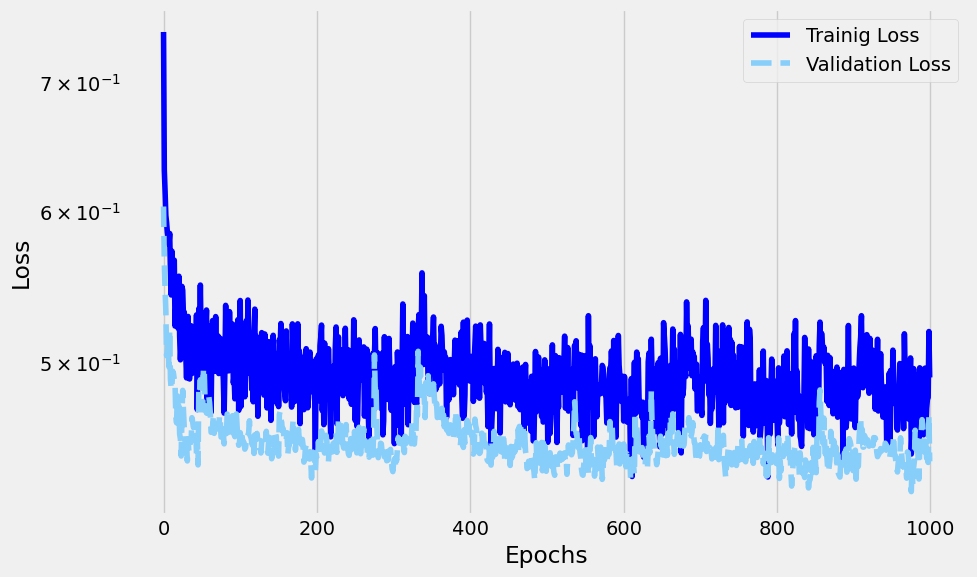

Accuracy: 0.8268156424581006
ROC-AUC: 0.8144787644787644


In [42]:
model_pe = NNTrainer(
    model=model,
    loss_fn=loss_fn,
    optimizer=optimizer,
    random_state=SEED
)
model_pe.fit(
    n_epochs=1000,
    x_cat=x_cat_train,
    x_con=x_con_train,
    y=y_train,
    val_data=(x_cat_val, x_con_val, y_val)
)
model_pe.plot_losses()
yhat_proba = model_pe.predict_proba(x_cat_val, x_con_val)
yhat = model_pe.predict(x_cat_val, x_con_val)
print(f'Accuracy: {accuracy_score(y_val, yhat)}')
print(f'ROC-AUC: {roc_auc_score(y_val, yhat)}')

In [43]:
model_pe.predict_proba(x_cat_val, x_con_val)

array([[0.37789118, 0.6221088 ],
       [0.7860239 , 0.2139761 ],
       [0.8262582 , 0.17374179],
       [0.1311804 , 0.8688196 ],
       [0.40547597, 0.594524  ],
       [0.13787282, 0.8621272 ],
       [0.468238  , 0.531762  ],
       [0.8139279 , 0.18607214],
       [0.44379693, 0.55620307],
       [0.1179713 , 0.8820287 ],
       [0.7318729 , 0.2681271 ],
       [0.83534825, 0.16465174],
       [0.81263226, 0.18736775],
       [0.79168904, 0.20831098],
       [0.8052309 , 0.19476907],
       [0.11878818, 0.8812118 ],
       [0.763463  , 0.23653695],
       [0.46782792, 0.5321721 ],
       [0.77014524, 0.22985475],
       [0.7979764 , 0.20202364],
       [0.84407973, 0.15592028],
       [0.81244385, 0.18755613],
       [0.58606166, 0.41393834],
       [0.82471836, 0.17528164],
       [0.8410329 , 0.15896708],
       [0.6976203 , 0.30237973],
       [0.68012834, 0.3198717 ],
       [0.78897125, 0.21102877],
       [0.7219176 , 0.27808237],
       [0.4783603 , 0.5216397 ],
       [0.